# 12. Explaining Ranking, Prioritization, and Policy Scores

The previous notebook studied counterfactual recourse for a single unfavorable decision. This notebook moves to a setting that is even more common in industry: **ranked action queues**.

Many deployed models produce a score that determines who gets called first, which fraud alerts are investigated, which customers receive specialist support, which maintenance tickets are escalated, which claims get clinical review, or which experiments are launched. In these systems, explanation concerns individual predictions as well as **position**, **capacity**, **margins**, **exposure**, and **policy**.

A ranking system answers a decision question like:

> Given limited capacity, which cases should receive attention first, and why are these cases above the cutoff?

That question is different from ordinary classification. A case can have a high predicted probability and still rank below the action cutoff if its expected value is small. Another case can have moderate risk but rank high because the opportunity value is large. A professional explanation must therefore explain the **score**, the **ordering**, and the **action policy** that turns ordering into resource allocation.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Distinguish point predictions, ranking scores, priority scores, and policy actions.
2. Evaluate ranked action lists using top-k value capture, precision at k, and NDCG.
3. Explain why an item is above or below a capacity cutoff.
4. Use local pairwise explanations to compare two ranked cases.
5. Diagnose whether score explanations differ from rank explanations.
6. Audit exposure across groups in a ranked queue.
7. Quantify rank instability near the cutoff.
8. Produce a professional explanation template for triage and prioritization systems.

## 1. Ranking Is A Decision Problem

Let $x_i$ denote the features for item $i$, and let a model produce a score

$$
s_i = f(x_i).
$$

A ranking is the ordering induced by these scores:

$$
\pi = \operatorname{argsort}_{i \in \mathcal I}(-s_i),
$$

where $\pi_1$ is the item in the first position, $\pi_2$ is the second item, and so on.

The decision rule usually adds capacity:

$$
a_i = \mathbb{1}\{\operatorname{rank}(i) \leq k\}.
$$

This small change matters. In classification, the key question is often whether $s_i$ crosses a threshold. In ranking, the key question is often whether $s_i$ is above enough **relative to other cases** to fit inside the top $k$. This creates three different explanation targets:

| Explanation target | Question being answered | Typical stakeholder |
|---|---|---|
| Score explanation | Why did this case receive score $s_i$? | Analyst, model reviewer |
| Rank explanation | Why is this case ranked above another case? | Queue manager, operations lead |
| Policy explanation | Why was this case selected for action under capacity $k$? | Business owner, governance reviewer |

Learning-to-rank methods formalize this distinction by optimizing order-sensitive objectives rather than ordinary pointwise error. RankNet is an early influential pairwise ranking method (Burges et al., 2005). Ranking evaluation often uses discounted metrics such as DCG and NDCG, which place more weight on errors near the top of the list (Järvelin & Kekäläinen, 2002).

## 2. Ranking Metrics We Will Use

For a ranked list $\pi$, discounted cumulative gain at depth $k$ is

$$
\operatorname{DCG}_k = \sum_{r=1}^{k} \frac{2^{\operatorname{rel}_{\pi_r}} - 1}{\log_2(r+1)}.
$$

The normalized version divides by the ideal DCG:

$$
\operatorname{NDCG}_k = \frac{\operatorname{DCG}_k}{\operatorname{IDCG}_k}.
$$

For decision systems, we often also need business metrics:

$$
\operatorname{ValueCapture}_k = \frac{\sum_{i \in \operatorname{TopK}(s)} v_i}{\sum_{i \in \operatorname{TopK}(v)} v_i},
$$

where $v_i$ is the true or audited value of acting on case $i$. This metric asks: how much of the best available value did the model capture with its top $k$ slots?

Precision at $k$ is useful when the decision is binary:

$$
\operatorname{Precision}_k = \frac{1}{k}\sum_{i \in \operatorname{TopK}(s)} y_i.
$$

Expected reciprocal rank is another family of graded relevance metrics that emphasizes early satisfaction in a ranked list (Chapelle et al., 2009). For this notebook, NDCG and value capture will be enough.

In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import average_precision_score, mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 2072
sns.set_theme(style='whitegrid', context='notebook')
np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.max_colwidth', 120)

In [2]:
# Section focus: 2. Ranking Metrics We Will Use.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def display_table(df, precision=3, max_width='480px'):
    """Display table for the 12. Explaining Ranking, Prioritization, and Policy Scores notebook output.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    precision : object
        Number of decimal places used when formatting numeric output.
    max_width : object
        Maximum display width used to keep rendered tables readable.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    styler = df.style.format(precision=precision)
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('white-space', 'normal'), ('text-align', 'left')]},
        {'selector': 'td', 'props': [('white-space', 'normal'), ('max-width', max_width), ('text-align', 'left'), ('vertical-align', 'top')]},
    ])
    display(styler)


def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-z))


def top_k_indices(scores, k):
    """Carry out the top k indices step used in the 12. Explaining Ranking, Prioritization, and Policy Scores workflow.
    
    Parameters
    ----------
    scores : object
        Model scores, risks, or anomaly scores used by the decision rule.
    k : object
        Count or size setting for the top k indices calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the top k indices calculation and reused by later cells.
    """
    scores = np.asarray(scores)
    return np.argsort(-scores)[:k]


def precision_at_k(labels, scores, k):
    """Carry out the precision at k step used in the 12. Explaining Ranking, Prioritization, and Policy Scores workflow.
    
    Parameters
    ----------
    labels : object
        Observed or assigned labels used for evaluation.
    scores : object
        Model scores, risks, or anomaly scores used by the decision rule.
    k : object
        Count or size setting for the precision at k calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the precision at k calculation and reused by later cells.
    """
    idx = top_k_indices(scores, k)
    return float(np.mean(np.asarray(labels)[idx]))


def value_capture_at_k(values, scores, k):
    """Carry out the value capture at k step used in the 12. Explaining Ranking, Prioritization, and Policy Scores workflow.
    
    Parameters
    ----------
    values : object
        The values setting that controls the value capture at k calculation in this notebook.
    scores : object
        Model scores, risks, or anomaly scores used by the decision rule.
    k : object
        Count or size setting for the value capture at k calculation.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the value capture at k calculation.
    """
    values = np.clip(np.asarray(values), 0, None)
    chosen = top_k_indices(scores, k)
    ideal = top_k_indices(values, k)
    denom = values[ideal].sum()
    return float(values[chosen].sum() / denom) if denom > 0 else np.nan


def ndcg_at_k(relevance, scores, k):
    """Carry out the ndcg at k step used in the 12. Explaining Ranking, Prioritization, and Policy Scores workflow.
    
    Parameters
    ----------
    relevance : object
        The relevance setting that controls the ndcg at k calculation in this notebook.
    scores : object
        Model scores, risks, or anomaly scores used by the decision rule.
    k : object
        Count or size setting for the ndcg at k calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the ndcg at k calculation and reused by later cells.
    """
    relevance = np.asarray(relevance)
    scores = np.asarray(scores)
    chosen = top_k_indices(scores, k)
    ideal = top_k_indices(relevance, k)
    discounts = 1 / np.log2(np.arange(2, k + 2))
    gains = np.power(2, relevance[chosen]) - 1
    ideal_gains = np.power(2, relevance[ideal]) - 1
    dcg = float(np.sum(gains * discounts))
    idcg = float(np.sum(ideal_gains * discounts))
    return dcg / idcg if idcg > 0 else np.nan


def rank_series(scores):
    """Carry out the rank series step used in the 12. Explaining Ranking, Prioritization, and Policy Scores workflow.
    
    Parameters
    ----------
    scores : object
        Model scores, risks, or anomaly scores used by the decision rule.
    
    Returns
    -------
    object
        Intermediate result produced by the rank series calculation and reused by later cells.
    """
    scores = pd.Series(scores)
    return scores.rank(ascending=False, method='first').astype(int)

The explanation result should be compared with the decision story. In Ranking Metrics We Will Use, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. In practice, a clearer explanation lowers review burden and makes the recommendation easier to defend.


## 3. Synthetic Decision Case: Customer Intervention Queue

We will build a synthetic prioritization system for a customer-success team. Every week the team can assign a specialist to only $k$ accounts. The model should rank accounts by expected value of intervention rather than churn risk alone.

The simplified value score is

$$
s_i = \widehat p_i \times \widehat u_i \times V_i - C_i,
$$

where:

- $\widehat p_i$ is predicted churn or escalation risk;
- $\widehat u_i$ is predicted intervention responsiveness;
- $V_i$ is account value;
- $C_i$ is intervention cost.

Its causal status requires separate evidence. The term $\widehat u_i$ should ideally come from experiments, uplift modeling, or credible causal evidence. Here we simulate it so that we can study explanation mechanics.

In [3]:
# Section focus: 3. Synthetic Decision Case: Customer Intervention Queue.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_priority_data(n=7200, seed=RANDOM_SEED):
    """Construct the priority data helper used in the 12. Explaining Ranking, Prioritization, and Policy Scores workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    account_size_z = rng.normal(0, 1, n)
    strategic_tier = rng.binomial(1, sigmoid(-0.25 + 0.95 * account_size_z), n)
    enterprise = rng.binomial(1, sigmoid(-0.55 + 0.85 * account_size_z + 0.50 * strategic_tier), n)
    public_sector = rng.binomial(1, sigmoid(-1.05 + 0.35 * enterprise - 0.20 * account_size_z), n)

    contract_value_k = np.exp(3.55 + 0.62 * account_size_z + 0.28 * strategic_tier + rng.normal(0, 0.22, n))
    renewal_pressure = np.clip(rng.beta(2.0 + 1.2 * enterprise, 4.8, n), 0.01, 0.98)
    usage_drop = np.clip(sigmoid(-0.45 + 0.85 * renewal_pressure - 0.30 * strategic_tier + rng.normal(0, 0.82, n)), 0.02, 0.98)
    training_gap = np.clip(sigmoid(-0.35 + 0.78 * usage_drop - 0.22 * enterprise + rng.normal(0, 0.70, n)), 0.02, 0.98)
    support_burden = rng.poisson(np.clip(np.exp(0.15 + 1.05 * usage_drop + 0.55 * training_gap + 0.28 * public_sector), 0.2, 9.0))
    billing_delay_days = np.clip(rng.gamma(1.4 + 0.42 * public_sector, 1.45, n), 0, 15)
    competitor_signal = np.clip(sigmoid(-1.05 + 1.15 * usage_drop + 0.34 * renewal_pressure + rng.normal(0, 0.80, n)), 0.01, 0.99)
    implementation_complexity = np.clip(sigmoid(-0.25 + 0.55 * enterprise + 0.65 * public_sector + 0.32 * support_burden / 5 + rng.normal(0, 0.65, n)), 0.02, 0.98)
    random_noise_feature = rng.normal(0, 1, n)

    churn_logit = (
        -3.00
        + 1.25 * usage_drop
        + 1.05 * training_gap
        + 0.16 * support_burden
        + 0.10 * billing_delay_days
        + 1.15 * competitor_signal
        + 0.55 * public_sector
        - 0.42 * strategic_tier
        + 0.85 * usage_drop * competitor_signal
    )
    true_churn_risk = sigmoid(churn_logit)
    would_churn_without_action = rng.binomial(1, true_churn_risk)

    uplift_logit = (
        -1.35
        + 1.15 * training_gap
        + 0.75 * usage_drop
        - 0.62 * implementation_complexity
        + 0.38 * strategic_tier
        - 0.28 * public_sector
        + rng.normal(0, 0.34, n)
    )
    true_intervention_response = sigmoid(uplift_logit)

    intervention_cost_k = (
        2.8
        + 0.050 * contract_value_k
        + 1.45 * enterprise
        + 0.42 * support_burden
        + 2.25 * implementation_complexity
    )
    true_priority_value_k = contract_value_k * true_churn_risk * true_intervention_response - intervention_cost_k
    observed_priority_value_k = true_priority_value_k + rng.normal(0, 4.5 + 0.055 * contract_value_k, n)
    profitable_action = (true_priority_value_k > np.quantile(true_priority_value_k, 0.72)).astype(int)

    return pd.DataFrame({
        'account_size_z': account_size_z,
        'strategic_tier': strategic_tier,
        'enterprise': enterprise,
        'public_sector': public_sector,
        'contract_value_k': contract_value_k,
        'renewal_pressure': renewal_pressure,
        'usage_drop': usage_drop,
        'training_gap': training_gap,
        'support_burden': support_burden,
        'billing_delay_days': billing_delay_days,
        'competitor_signal': competitor_signal,
        'implementation_complexity': implementation_complexity,
        'random_noise_feature': random_noise_feature,
        'true_churn_risk': true_churn_risk,
        'would_churn_without_action': would_churn_without_action,
        'true_intervention_response': true_intervention_response,
        'intervention_cost_k': intervention_cost_k,
        'true_priority_value_k': true_priority_value_k,
        'observed_priority_value_k': observed_priority_value_k,
        'profitable_action': profitable_action,
    })


df = make_priority_data()
FEATURES = [
    'account_size_z', 'strategic_tier', 'enterprise', 'public_sector', 'contract_value_k',
    'renewal_pressure', 'usage_drop', 'training_gap', 'support_burden', 'billing_delay_days',
    'competitor_signal', 'implementation_complexity', 'random_noise_feature'
]

train_df, test_df = train_test_split(df, test_size=0.32, random_state=RANDOM_SEED, stratify=df['profitable_action'])

summary = pd.DataFrame([
    {'quantity': 'Rows', 'value': len(df)},
    {'quantity': 'Train rows', 'value': len(train_df)},
    {'quantity': 'Test rows', 'value': len(test_df)},
    {'quantity': 'Mean true churn risk', 'value': df['true_churn_risk'].mean()},
    {'quantity': 'Mean true intervention response', 'value': df['true_intervention_response'].mean()},
    {'quantity': 'Mean true priority value, $000s', 'value': df['true_priority_value_k'].mean()},
    {'quantity': 'Share labeled profitable action', 'value': df['profitable_action'].mean()},
])

display_table(summary)
display_table(df[FEATURES + ['true_churn_risk', 'true_intervention_response', 'true_priority_value_k', 'profitable_action']].head(6))

,quantity,value
0,Rows,7200.000
1,Train rows,4896.000
2,Test rows,2304.000
3,Mean true churn risk,0.350
4,Mean true intervention response,0.331
5,"Mean true priority value, $000s",-2.635
6,Share labeled profitable action,0.280


,account_size_z,strategic_tier,enterprise,public_sector,contract_value_k,renewal_pressure,usage_drop,training_gap,support_burden,billing_delay_days,competitor_signal,implementation_complexity,random_noise_feature,true_churn_risk,true_intervention_response,true_priority_value_k,profitable_action
0,-0.833,0,0,1,27.341,0.353,0.331,0.683,5,1.537,0.194,0.825,-2.837,0.478,0.226,-5.168,0
1,-0.508,0,1,0,26.195,0.494,0.699,0.320,0,0.518,0.492,0.554,-0.562,0.293,0.287,-4.600,0
2,-1.172,0,1,1,19.809,0.203,0.145,0.510,5,0.541,0.112,0.713,0.031,0.324,0.268,-7.229,0
3,-1.033,0,0,1,16.438,0.162,0.254,0.730,5,4.950,0.351,0.580,-2.148,0.601,0.255,-4.507,0
4,0.025,1,0,1,36.233,0.492,0.583,0.868,3,0.880,0.257,0.725,0.595,0.441,0.396,-1.180,1
5,-1.062,0,1,1,11.998,0.373,0.462,0.913,0,0.349,0.184,0.636,-0.906,0.356,0.265,-5.148,0


The metric result should be read as an operating tradeoff. In Synthetic Decision Case: Customer Intervention Queue, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. The number should be interpreted through the decision it supports.


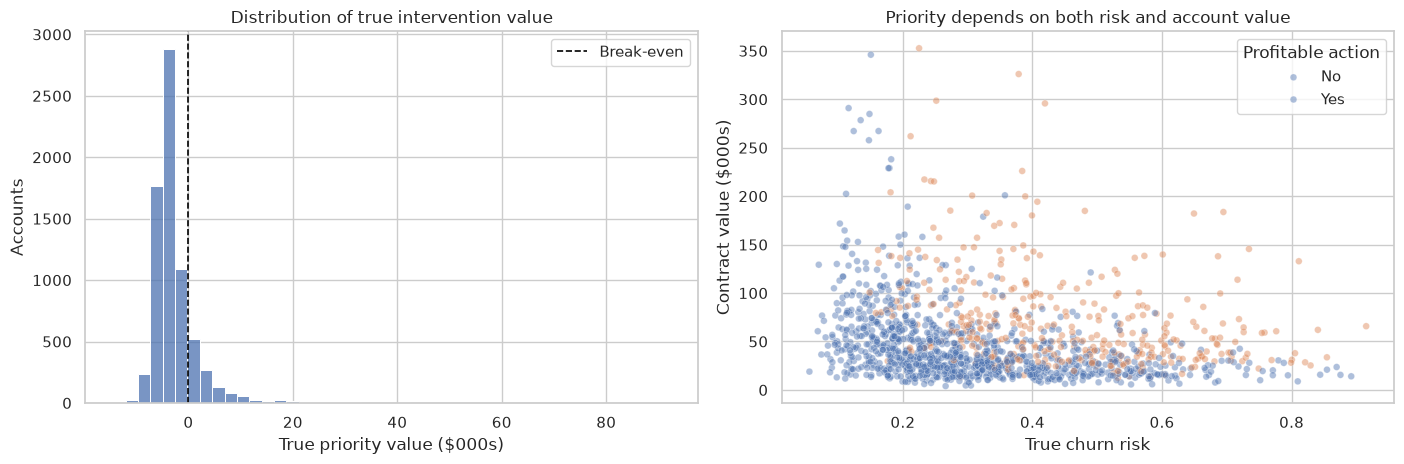

In [4]:
# Section focus: 3. Synthetic Decision Case: Customer Intervention Queue.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

fig, axes = plt.subplots(1, 2, figsize=(14.2, 4.8))

sns.histplot(df['true_priority_value_k'], bins=45, ax=axes[0], color='#4c72b0')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='Break-even')
axes[0].set_title('Distribution of true intervention value')
axes[0].set_xlabel('True priority value ($000s)')
axes[0].set_ylabel('Accounts')
axes[0].legend()

sns.scatterplot(
    data=df.sample(1400, random_state=RANDOM_SEED),
    x='true_churn_risk',
    y='contract_value_k',
    hue='profitable_action',
    palette={0: '#4c72b0', 1: '#dd8452'},
    alpha=0.45,
    s=24,
    ax=axes[1],
)
axes[1].set_title('Priority depends on both risk and account value')
axes[1].set_xlabel('True churn risk')
axes[1].set_ylabel('Contract value ($000s)')
axes[1].legend(title='Profitable action', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

The explanation result should be compared with the decision story. In Synthetic Decision Case: Customer Intervention Queue, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. Weak explanations push the hard work back onto the reviewer.


### Discussion of The Data-Generating Process

The scatterplot is the first warning against simplistic explanation. A high-risk account is not always the highest priority. The action queue should also account for value, likely responsiveness, and cost. That means a policy-score explanation must say whether the item is high because of risk, value, response likelihood, low cost, or a combination.

The notebook uses simulated true quantities so that ranking metrics can be checked. In real systems, the true action value is usually only partially observed and can be affected by selection bias: teams observe outcomes for cases they acted on more often than for cases they ignored.

## 4. Fit Risk and Priority Models

We will fit two models:

1. A **risk-only model** that predicts whether the account would churn without action.
2. A **value-aware priority model** that predicts observed intervention value.

The risk-only model can be accurate and still be the wrong ranking model for a constrained action queue. The value-aware model is closer to the decision objective, though it still depends on whether observed value is measured fairly.

In [5]:
# Section focus: 4. Fit Risk and Priority Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

risk_model = HistGradientBoostingClassifier(
    max_iter=220,
    learning_rate=0.055,
    max_leaf_nodes=22,
    l2_regularization=0.02,
    random_state=RANDOM_SEED,
)
risk_model.fit(train_df[FEATURES], train_df['would_churn_without_action'])

priority_model = HistGradientBoostingRegressor(
    max_iter=260,
    learning_rate=0.05,
    max_leaf_nodes=26,
    l2_regularization=0.03,
    random_state=RANDOM_SEED,
)
priority_model.fit(train_df[FEATURES], train_df['observed_priority_value_k'])

rf_priority_model = RandomForestRegressor(
    n_estimators=240,
    min_samples_leaf=18,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_priority_model.fit(train_df[FEATURES], train_df['observed_priority_value_k'])

test_eval = test_df.copy()
test_eval['risk_score'] = risk_model.predict_proba(test_df[FEATURES])[:, 1]
test_eval['priority_score'] = priority_model.predict(test_df[FEATURES])
test_eval['rf_priority_score'] = rf_priority_model.predict(test_df[FEATURES])
test_eval['random_score'] = np.random.default_rng(RANDOM_SEED).normal(size=len(test_eval))

risk_auc = roc_auc_score(test_eval['would_churn_without_action'], test_eval['risk_score'])
risk_ap = average_precision_score(test_eval['would_churn_without_action'], test_eval['risk_score'])
priority_rmse = mean_squared_error(test_eval['observed_priority_value_k'], test_eval['priority_score']) ** 0.5
priority_mae = mean_absolute_error(test_eval['observed_priority_value_k'], test_eval['priority_score'])
rf_rmse = mean_squared_error(test_eval['observed_priority_value_k'], test_eval['rf_priority_score']) ** 0.5

model_summary = pd.DataFrame([
    {'model': 'Risk-only churn model', 'task_metric': 'ROC AUC', 'value': risk_auc},
    {'model': 'Risk-only churn model', 'task_metric': 'Average precision', 'value': risk_ap},
    {'model': 'Value-aware priority model', 'task_metric': 'RMSE on observed value', 'value': priority_rmse},
    {'model': 'Value-aware priority model', 'task_metric': 'MAE on observed value', 'value': priority_mae},
    {'model': 'Random forest priority model', 'task_metric': 'RMSE on observed value', 'value': rf_rmse},
])
display_table(model_summary)

,model,task_metric,value
0,Risk-only churn model,ROC AUC,0.673
1,Risk-only churn model,Average precision,0.531
2,Value-aware priority model,RMSE on observed value,8.564
3,Value-aware priority model,MAE on observed value,6.396
4,Random forest priority model,RMSE on observed value,8.436


This result is an interpretation diagnostic. For Fit Risk and Priority Models, look at whether the explanation is stable, plausible, and useful for stakeholder review. Even a fragile story can help, provided the analyst states where it changes.


### Discussion of Model Quality

Model quality is necessary but not sufficient. The risk model can separate likely churners from non-churners, but a top-k action queue is not necessarily trying to maximize churn detection. It is trying to allocate scarce action capacity to cases where action is expected to matter.

The value-aware model has a regression error because the observed value target is noisy. That uncertainty should appear in the ranking explanation: cases near the cutoff should be treated as unstable, not as sharply different from the cases immediately below them.

## 5. Compare Risk-Only and Value-Aware Rankings

We evaluate each score using the same top-k decision rule. For the examples below, the team can act on $k=60$ accounts.

The ranked list is useful only if its top positions capture a large share of the best available action value. This is why we compare:

- precision at $k$ for profitable actions;
- NDCG at $k$ using graded relevance from true value;
- value capture at $k$;
- average true value of the selected accounts.

In [6]:
# Section focus: 5. Compare Risk-Only and Value-Aware Rankings.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

K = 60
true_value = test_eval['true_priority_value_k'].to_numpy()
relevance = pd.qcut(test_eval['true_priority_value_k'], q=8, labels=False, duplicates='drop').to_numpy()
labels = test_eval['profitable_action'].to_numpy()

score_columns = {
    'Risk-only ranking': 'risk_score',
    'Value-aware priority ranking': 'priority_score',
    'Random forest priority ranking': 'rf_priority_score',
    'Random ranking': 'random_score',
}

ranking_rows = []
for name, col in score_columns.items():
    idx = top_k_indices(test_eval[col], K)
    ranking_rows.append({
        'ranking': name,
        'precision_at_60': precision_at_k(labels, test_eval[col], K),
        'ndcg_at_60': ndcg_at_k(relevance, test_eval[col], K),
        'positive_value_capture_at_60': value_capture_at_k(true_value, test_eval[col], K),
        'mean_true_value_top_60': true_value[idx].mean(),
        'total_true_value_top_60': true_value[idx].sum(),
        'mean_contract_value_top_60': test_eval.iloc[idx]['contract_value_k'].mean(),
        'mean_risk_top_60': test_eval.iloc[idx]['true_churn_risk'].mean(),
    })
ranking_metrics = pd.DataFrame(ranking_rows).sort_values('positive_value_capture_at_60', ascending=False)
display_table(ranking_metrics)

,ranking,precision_at_60,ndcg_at_60,positive_value_capture_at_60,mean_true_value_top_60,total_true_value_top_60,mean_contract_value_top_60,mean_risk_top_60
1,Value-aware priority ranking,0.933,0.926,0.823,15.021,901.264,173.515,0.475
2,Random forest priority ranking,0.933,0.918,0.790,14.229,853.748,183.713,0.427
0,Risk-only ranking,0.583,0.476,0.188,1.541,92.439,46.735,0.684
3,Random ranking,0.250,0.216,0.059,-2.640,-158.405,55.030,0.353


Use the explanation as a stress test of the model narrative. In Compare Risk-Only and Value-Aware Rankings, the displayed reasons should make sense with the data-generating story and the operating decision. Disagreement across explanation views changes how confidently the result can be communicated.


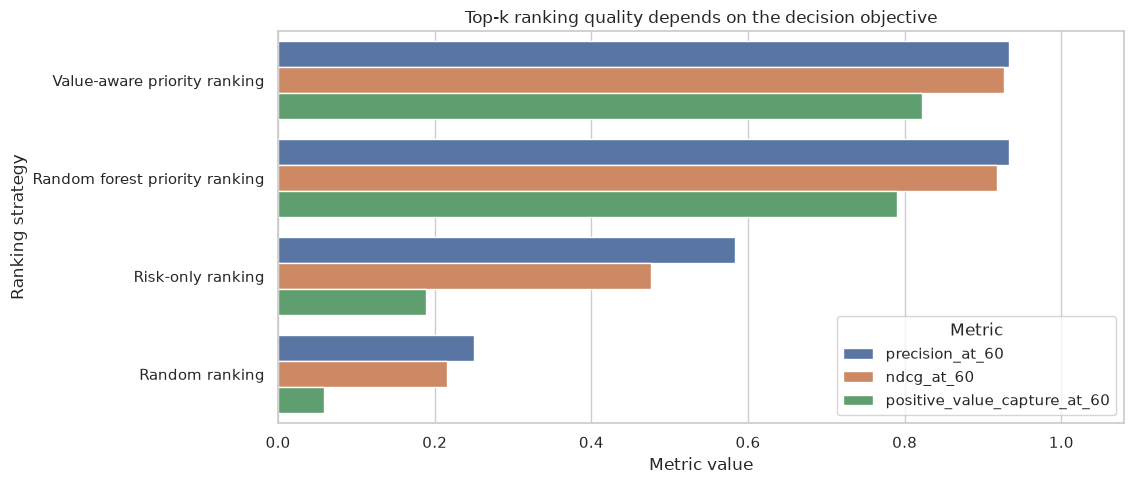

In [7]:
plot_metrics = ranking_metrics.melt(
    id_vars='ranking',
    value_vars=['precision_at_60', 'ndcg_at_60', 'positive_value_capture_at_60'],
    var_name='metric',
    value_name='value',
)
fig, ax = plt.subplots(figsize=(11.5, 5.0))
sns.barplot(data=plot_metrics, x='value', y='ranking', hue='metric', ax=ax, palette='deep')
ax.set_title('Top-k ranking quality depends on the decision objective')
ax.set_xlabel('Metric value')
ax.set_ylabel('Ranking strategy')
ax.set_xlim(0, 1.08)
ax.legend(title='Metric', loc='lower right')
plt.tight_layout()
plt.show()

The explanation result should be compared with the decision story. In Compare Risk-Only and Value-Aware Rankings, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. A clear explanation lowers ambiguity for the stakeholder and makes review more focused.


### Discussion of Ranking Metrics

The value-aware score should usually dominate risk-only ranking on value capture because it is closer to the operational objective. A risk-only score may still perform well on precision if many high-risk accounts are also profitable to intervene on. But when value, cost, and response vary, ranking by risk alone can waste scarce capacity.

This is an important explanation lesson: saying "this case is high risk" is not enough if the policy is actually "select the highest expected action value." The explanation must match the score used for the decision.

## 6. Top-k Cutoffs and Rank Margins

A ranking system creates a cutoff case. The difference between rank $60$ and rank $61$ may be tiny. In these situations, a professional explanation should include a **rank margin**:

$$
\operatorname{margin}_i = s_i - s_{\pi_k}.
$$

Large positive margins indicate stable inclusion. Near-zero margins indicate cases that are sensitive to model retraining, measurement noise, or small policy changes.

,priority_rank,priority_score,score_margin_to_cutoff,true_priority_value_k,true_churn_risk,true_intervention_response,contract_value_k,profitable_action,strategic_tier,public_sector
2786,54,11.466,0.731,11.788,0.664,0.423,85.714,1,0,0
4405,55,11.250,0.516,10.864,0.651,0.549,55.302,1,0,0
202,56,11.070,0.335,8.418,0.331,0.446,159.279,1,1,0
5229,57,11.010,0.276,19.754,0.569,0.434,135.709,1,1,1
4854,58,10.939,0.205,7.379,0.247,0.532,167.462,1,1,0
2840,59,10.828,0.093,14.030,0.489,0.457,107.284,1,1,1
1767,60,10.735,0.000,-12.814,0.065,0.302,259.035,0,1,0
2808,61,10.619,-0.115,10.323,0.372,0.558,110.070,1,1,0
5126,62,10.481,-0.253,11.310,0.405,0.339,215.661,1,1,0
6889,63,10.447,-0.288,11.723,0.695,0.542,54.858,1,0,0


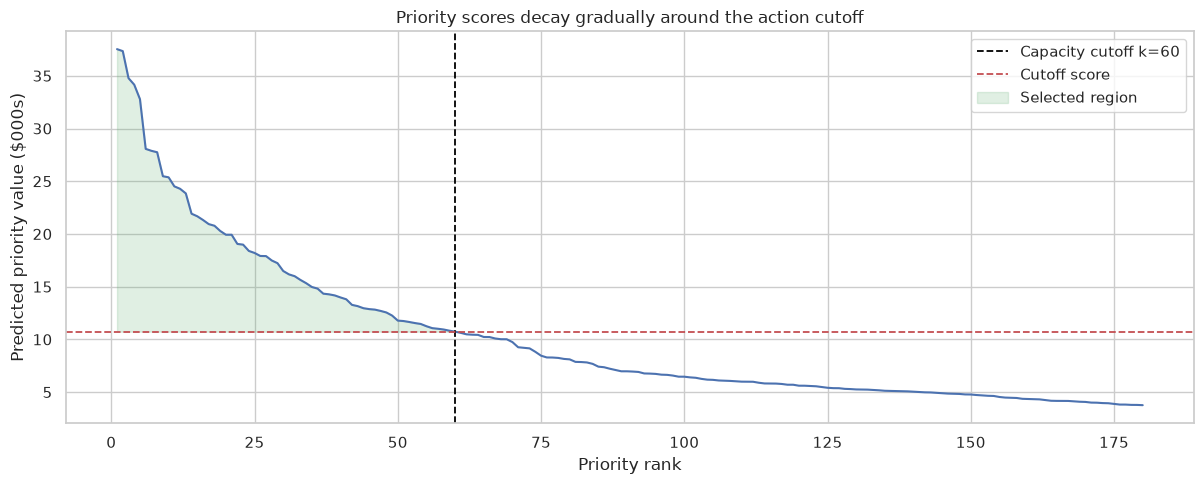

In [8]:
# Section focus: 6. Top-k Cutoffs and Rank Margins.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

test_eval = test_eval.sort_values('priority_score', ascending=False).copy()
test_eval['priority_rank'] = np.arange(1, len(test_eval) + 1)
cutoff_score = float(test_eval.loc[test_eval['priority_rank'].eq(K), 'priority_score'].iloc[0])
test_eval['score_margin_to_cutoff'] = test_eval['priority_score'] - cutoff_score
test_eval['selected_by_priority_policy'] = test_eval['priority_rank'] <= K

near_cutoff = test_eval.loc[test_eval['priority_rank'].between(K - 6, K + 7), [
    'priority_rank', 'priority_score', 'score_margin_to_cutoff', 'true_priority_value_k',
    'true_churn_risk', 'true_intervention_response', 'contract_value_k', 'profitable_action',
    'strategic_tier', 'public_sector'
]].copy()

display_table(near_cutoff)

fig, ax = plt.subplots(figsize=(12.2, 5.0))
rank_plot = test_eval.head(180).copy()
sns.lineplot(data=rank_plot, x='priority_rank', y='priority_score', ax=ax, color='#4c72b0')
ax.axvline(K, color='black', linestyle='--', linewidth=1.3, label=f'Capacity cutoff k={K}')
ax.axhline(cutoff_score, color='#c44e52', linestyle='--', linewidth=1.3, label='Cutoff score')
ax.fill_between(rank_plot['priority_rank'], cutoff_score, rank_plot['priority_score'], where=rank_plot['priority_score'] >= cutoff_score, color='#55a868', alpha=0.18, label='Selected region')
ax.set_title('Priority scores decay gradually around the action cutoff')
ax.set_xlabel('Priority rank')
ax.set_ylabel('Predicted priority value ($000s)')
ax.legend()
plt.tight_layout()
plt.show()

The metric result should be read as an operating tradeoff. In Top-k Cutoffs and Rank Margins, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. The metric should now be translated into cost, risk, capacity, or stakeholder action.


### Discussion of Cutoff Explanations

The cases just above and below the cutoff should not be described as fundamentally different unless the score margin is large. Because this is a simulated notebook, we can also see the hidden truth: some near-cutoff cases just below the boundary have higher realized value than the cutoff case. In production, that hidden truth is unavailable, so margin and uncertainty reporting become even more important. A good operational explanation distinguishes:

- **selected with margin**: clearly above the capacity boundary;
- **selected near cutoff**: selected, but sensitive to small changes;
- **not selected near cutoff**: not selected under current capacity, but a plausible candidate if capacity expands;
- **not selected with negative margin**: far below current action priority.

This framing is more honest than presenting the top-k boundary as a hard scientific truth.

## 7. Global Explanation of The Priority Score

A score explanation asks why the model assigns high priority values. We will use permutation importance on the value-aware priority model. This is a global diagnostic: it asks how much prediction quality deteriorates when a feature is shuffled.

Permutation importance is not causal. If two features are correlated, shuffling one feature may understate or overstate its role. Still, it is a useful first pass for explaining what the score function uses.

,feature,importance_mean,importance_std
4,contract_value_k,0.878,0.064
6,usage_drop,0.525,0.036
10,competitor_signal,0.272,0.060
7,training_gap,0.267,0.053
0,account_size_z,0.131,0.035
11,implementation_complexity,0.040,0.037
9,billing_delay_days,0.040,0.032
8,support_burden,0.032,0.018
12,random_noise_feature,0.021,0.022
1,strategic_tier,0.019,0.011


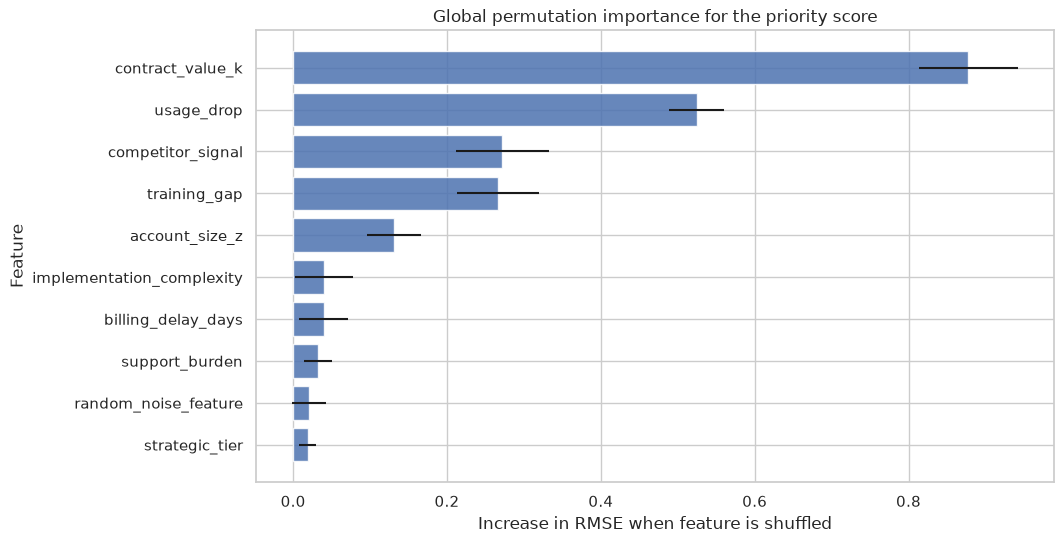

In [9]:
# Section focus: 7. Global Explanation of The Priority Score.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

perm = permutation_importance(
    priority_model,
    test_eval[FEATURES],
    test_eval['observed_priority_value_k'],
    n_repeats=8,
    random_state=RANDOM_SEED,
    scoring='neg_root_mean_squared_error',
)
importance = (
    pd.DataFrame({
        'feature': FEATURES,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
    })
    .sort_values('importance_mean', ascending=False)
)

display_table(importance.head(10))

fig, ax = plt.subplots(figsize=(10.8, 5.6))
plot_imp = importance.head(10).sort_values('importance_mean', ascending=True)
ax.barh(plot_imp['feature'], plot_imp['importance_mean'], xerr=plot_imp['importance_std'], color='#4c72b0', alpha=0.85)
ax.set_title('Global permutation importance for the priority score')
ax.set_xlabel('Increase in RMSE when feature is shuffled')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

Use the explanation as a stress test of the model narrative. In Global Explanation of The Priority Score, the displayed reasons should make sense with the data-generating story and the operating decision. When the local story changes across methods, the explanation should stay in analyst review.


### Discussion of Global Importance

In this simulated system, the priority score should care about value, risk, response, and cost drivers. Contract value, usage drop, training gap, support burden, and competitor signal should usually matter. If a random noise feature appears highly important, that would be a governance warning.

A global explanation is useful for model review, but it does not answer why a specific account is ranked above another account. For that, we need local or pairwise explanations.

## 8. Local Pairwise Explanation: Why This Case Is Above That Case

Ranking decisions are inherently comparative. Suppose an operations lead asks:

> Why is account A selected, while account B just below the cutoff is not?

A useful answer compares the two accounts with respect to the score model. We will fit a local linear surrogate around the cutoff region and decompose the score difference:

$$
\widehat s_A - \widehat s_B \approx \sum_j \widehat \beta_j \left(z_{Aj} - z_{Bj}\right),
$$

where $z_j$ denotes standardized features. This is similar in spirit to local surrogate explanations such as LIME, which approximates complex model behavior locally with an interpretable model (Ribeiro et al., 2016). Here the target is not a class label; it is the **priority score difference**.

In [10]:
# Section focus: 8. Local Pairwise Explanation: Why This Case Is Above That Case.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

selected_case = test_eval.loc[test_eval['priority_rank'].eq(K - 2)].iloc[0]
near_miss_case = test_eval.loc[test_eval['priority_rank'].eq(K + 2)].iloc[0]

scaler = StandardScaler().fit(train_df[FEATURES])
X_pool = test_eval[FEATURES].copy()
X_pool_scaled = scaler.transform(X_pool)
center = ((selected_case[FEATURES].to_numpy(dtype=float) + near_miss_case[FEATURES].to_numpy(dtype=float)) / 2).reshape(1, -1)
center_scaled = scaler.transform(pd.DataFrame(center, columns=FEATURES))[0]
distances = np.sqrt(((X_pool_scaled - center_scaled) ** 2).sum(axis=1))
bandwidth = np.quantile(distances, 0.30)
weights = np.exp(-(distances ** 2) / (2 * bandwidth ** 2))

local_target = priority_model.predict(X_pool)
local_surrogate = Ridge(alpha=0.25)
local_surrogate.fit(X_pool_scaled, local_target, sample_weight=weights)
local_r2 = local_surrogate.score(X_pool_scaled, local_target, sample_weight=weights)

selected_scaled = scaler.transform(pd.DataFrame([selected_case[FEATURES]], columns=FEATURES))[0]
near_miss_scaled = scaler.transform(pd.DataFrame([near_miss_case[FEATURES]], columns=FEATURES))[0]
contrib = local_surrogate.coef_ * (selected_scaled - near_miss_scaled)

pairwise_table = pd.DataFrame({
    'feature': FEATURES,
    'selected_value': selected_case[FEATURES].to_numpy(dtype=float),
    'near_miss_value': near_miss_case[FEATURES].to_numpy(dtype=float),
    'standardized_difference': selected_scaled - near_miss_scaled,
    'local_surrogate_coefficient': local_surrogate.coef_,
    'contribution_to_selected_minus_near_miss': contrib,
}).assign(abs_contribution=lambda d: d['contribution_to_selected_minus_near_miss'].abs())

pair_summary = pd.DataFrame([
    {'quantity': 'Selected case rank', 'value': int(selected_case['priority_rank'])},
    {'quantity': 'Near-miss case rank', 'value': int(near_miss_case['priority_rank'])},
    {'quantity': 'Selected predicted priority score', 'value': selected_case['priority_score']},
    {'quantity': 'Near-miss predicted priority score', 'value': near_miss_case['priority_score']},
    {'quantity': 'Observed score difference', 'value': selected_case['priority_score'] - near_miss_case['priority_score']},
    {'quantity': 'Local surrogate weighted R-squared', 'value': local_r2},
])

display_table(pair_summary)
display_table(pairwise_table.sort_values('abs_contribution', ascending=False).head(9).drop(columns='abs_contribution'))

,quantity,value
0,Selected case rank,58.000
1,Near-miss case rank,62.000
2,Selected predicted priority score,10.939
3,Near-miss predicted priority score,10.481
4,Observed score difference,0.458
5,Local surrogate weighted R-squared,0.535


,feature,selected_value,near_miss_value,standardized_difference,local_surrogate_coefficient,contribution_to_selected_minus_near_miss
4,contract_value_k,167.462,215.661,-1.088,2.715,-2.954
10,competitor_signal,0.301,0.817,-2.909,1.007,-2.928
6,usage_drop,0.633,0.382,1.382,1.711,2.365
7,training_gap,0.593,0.456,0.847,1.529,1.295
8,support_burden,1.000,4.000,-1.643,0.306,-0.502
5,renewal_pressure,0.317,0.477,-0.935,0.528,-0.493
11,implementation_complexity,0.698,0.719,-0.124,-0.911,0.113
9,billing_delay_days,2.231,2.336,-0.057,0.990,-0.057
12,random_noise_feature,-1.151,-1.361,0.212,0.096,0.020


Local Pairwise Explanation: Why This Case Is Above That Case is a check on the model narrative. The explanation is useful when the reasons fit the data story, the decision context, and the limits of the method.


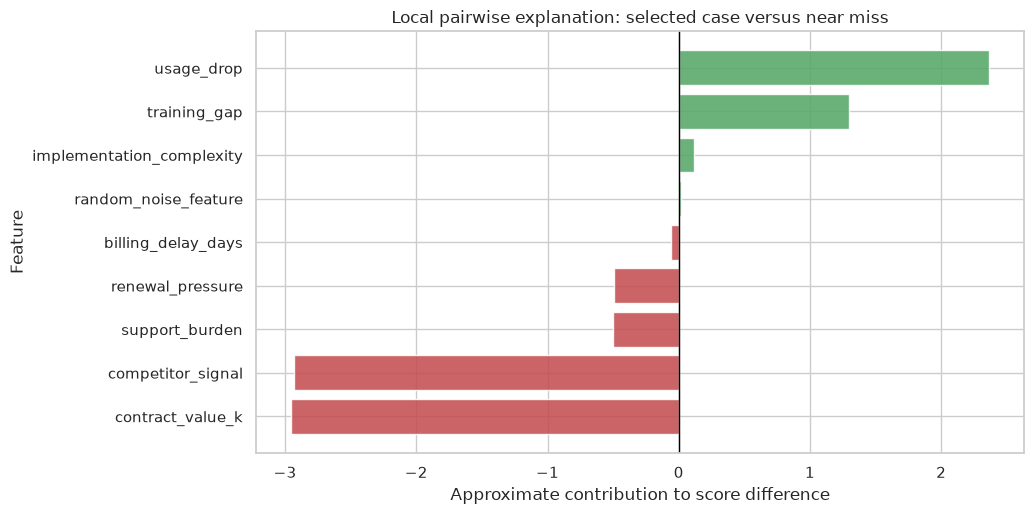

In [11]:
fig, ax = plt.subplots(figsize=(10.5, 5.3))
plot_pair = (
    pairwise_table.assign(abs_contribution=lambda d: d['contribution_to_selected_minus_near_miss'].abs())
    .sort_values('abs_contribution', ascending=False)
    .head(9)
    .sort_values('contribution_to_selected_minus_near_miss')
)
colors = np.where(plot_pair['contribution_to_selected_minus_near_miss'] >= 0, '#55a868', '#c44e52')
ax.barh(plot_pair['feature'], plot_pair['contribution_to_selected_minus_near_miss'], color=colors, alpha=0.88)
ax.axvline(0, color='black', linewidth=1.0)
ax.set_title('Local pairwise explanation: selected case versus near miss')
ax.set_xlabel('Approximate contribution to score difference')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

For Local Pairwise Explanation: Why This Case Is Above That Case, the right question is whether this explanation can survive baseline, sample, or neighborhood changes.


### Discussion of Pairwise Explanation

The pairwise explanation answers a different question from global importance. A feature can be globally important but irrelevant for a particular comparison if the two accounts have similar values on that feature. Conversely, a modest global feature can explain a specific rank difference if the two accounts differ sharply on it.

In this run, the selected case is not better on every dimension. Higher usage drop and training gap push it above the near miss, while lower contract value and lower competitor signal push in the opposite direction. That is the right kind of ranking explanation: it shows the tradeoff that produced the ordering, rather than pretending every feature favors the selected case.

The local surrogate quality matters. In this run, the weighted $R^2$ is only moderate, which is itself instructive: a linear local story can be useful for communication, but it should be reported as an approximation rather than as a faithful decomposition of the full black-box ranker. If the weighted $R^2$ is poor, the decomposition should be treated as a rough narrative rather than a reliable explanation.

## 9. Risk Ranking Versus Value Ranking

Now we compare which accounts are selected by a risk-only policy and by a value-aware policy. This is often where explanation becomes organizationally important: a stakeholder may expect the highest-risk cases to be selected, while the decision system selects cases with the highest expected action value.

,selection_group,accounts,mean_true_churn_risk,mean_response,mean_contract_value,mean_cost,mean_true_priority_value
0,Risk-only top-k only,56,0.690,0.332,37.664,8.906,-0.511
1,Selected by both,4,0.598,0.400,173.726,16.368,30.264
2,Value-aware top-k only,56,0.466,0.400,173.500,15.387,13.932


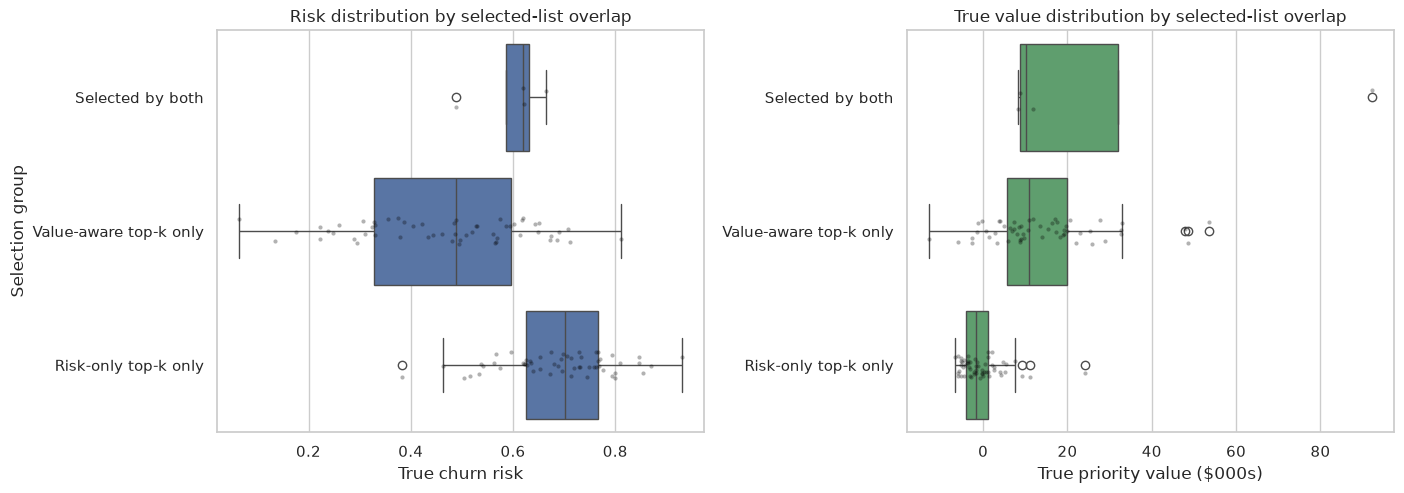

In [12]:
# Section focus: 9. Risk Ranking Versus Value Ranking.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

risk_top = set(test_eval.sort_values('risk_score', ascending=False).head(K).index)
value_top = set(test_eval.sort_values('priority_score', ascending=False).head(K).index)
comparison_membership = []
for idx, row in test_eval.iterrows():
    if idx in risk_top and idx in value_top:
        group = 'Selected by both'
    elif idx in risk_top:
        group = 'Risk-only top-k only'
    elif idx in value_top:
        group = 'Value-aware top-k only'
    else:
        continue
    comparison_membership.append({
        'row_index': idx,
        'selection_group': group,
        'risk_score': row['risk_score'],
        'priority_score': row['priority_score'],
        'true_churn_risk': row['true_churn_risk'],
        'true_intervention_response': row['true_intervention_response'],
        'contract_value_k': row['contract_value_k'],
        'intervention_cost_k': row['intervention_cost_k'],
        'true_priority_value_k': row['true_priority_value_k'],
    })
selection_compare = pd.DataFrame(comparison_membership)

selection_summary = (
    selection_compare.groupby('selection_group')
    .agg(
        accounts=('row_index', 'count'),
        mean_true_churn_risk=('true_churn_risk', 'mean'),
        mean_response=('true_intervention_response', 'mean'),
        mean_contract_value=('contract_value_k', 'mean'),
        mean_cost=('intervention_cost_k', 'mean'),
        mean_true_priority_value=('true_priority_value_k', 'mean'),
    )
    .reset_index()
)

display_table(selection_summary)

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.1))
sns.boxplot(data=selection_compare, x='true_churn_risk', y='selection_group', ax=axes[0], color='#4c72b0')
sns.stripplot(data=selection_compare, x='true_churn_risk', y='selection_group', ax=axes[0], color='black', alpha=0.30, size=3)
axes[0].set_title('Risk distribution by selected-list overlap')
axes[0].set_xlabel('True churn risk')
axes[0].set_ylabel('Selection group')

sns.boxplot(data=selection_compare, x='true_priority_value_k', y='selection_group', ax=axes[1], color='#55a868')
sns.stripplot(data=selection_compare, x='true_priority_value_k', y='selection_group', ax=axes[1], color='black', alpha=0.30, size=3)
axes[1].set_title('True value distribution by selected-list overlap')
axes[1].set_xlabel('True priority value ($000s)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

The result matters because it links evidence with deployment. The useful reading is which metric would change the action in Risk Ranking Versus Value Ranking. Different metrics often point to different actions, so the priority has to be explicit.


### Discussion of Policy Difference

The accounts selected only by the risk policy tend to be cases where risk is high enough to attract attention. The accounts selected only by the value-aware policy may have lower risk but greater value, response likelihood, or lower cost. Both rankings may be defensible, but they correspond to different objectives.

This is why a deployed system should document its score semantics. A queue called "highest-risk accounts" and a queue called "highest expected intervention value" are not the same product.

## 10. Exposure Diagnostics For Ranked Queues

Ranking allocates **exposure**. Position 1 receives more attention than position 60, and position 60 receives more attention than position 600. Fairness of exposure work studies whether exposure is allocated in ways that are consistent with merit and constraints (Singh & Joachims, 2018).

For a group $g$, define position exposure at depth $k$ as

$$
E_g = \sum_{r=1}^{k} \mathbb{1}\{G_{\pi_r}=g\} \cdot v_r,
\quad
v_r = \frac{1}{\log_2(r+1)}.
$$

We compare exposure share to merit share. Here merit is measured by positive true priority value. In practice, the definition of merit is a governance choice and should be debated carefully.

,ranking,group_label,selected_count,exposure_share,merit_share,exposure_minus_merit
0,Risk-only ranking,Commercial,23,0.327,0.648,-0.321
1,Risk-only ranking,Public sector,37,0.673,0.352,0.321
2,Value-aware ranking,Commercial,36,0.610,0.648,-0.038
3,Value-aware ranking,Public sector,24,0.390,0.352,0.038


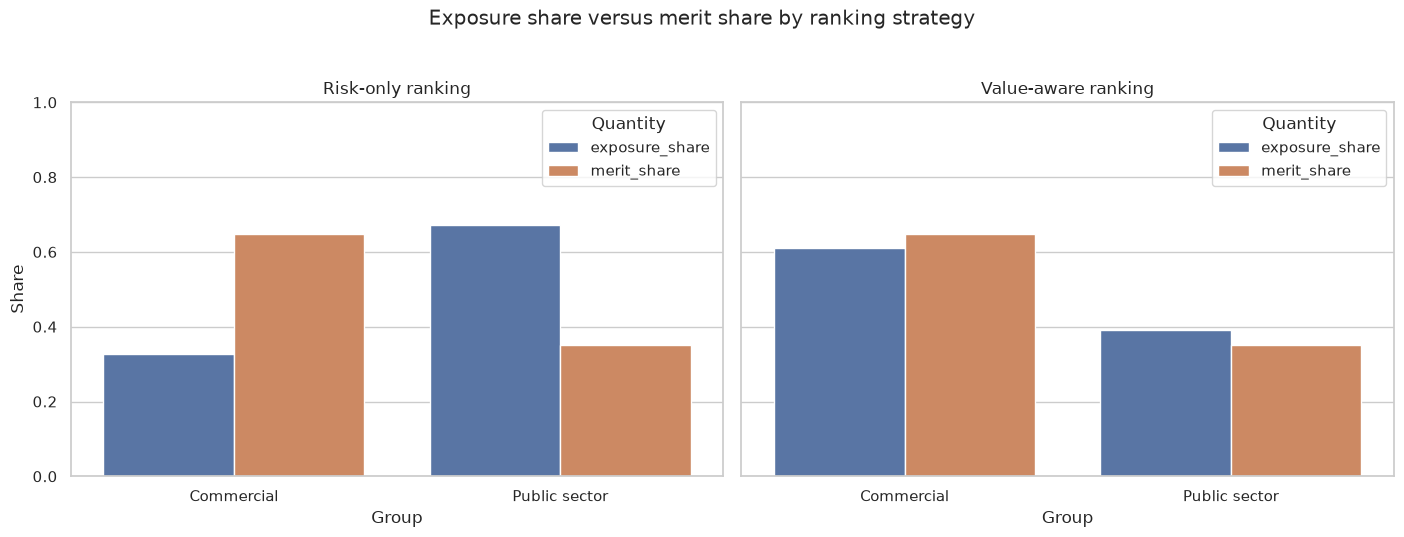

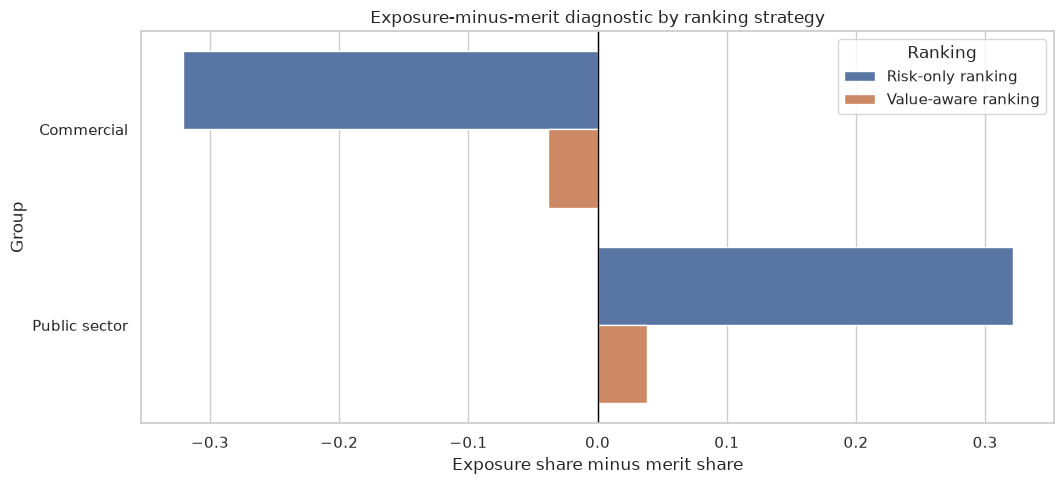

In [13]:
# Section focus: 10. Exposure Diagnostics For Ranked Queues.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def exposure_by_group(frame, score_col, group_col, k=K):
    """Carry out the exposure by group step used in the 12. Explaining Ranking, Prioritization, and Policy Scores workflow.
    
    Parameters
    ----------
    frame : object
        Data frame containing the units evaluated by this helper.
    score_col : object
        Column name containing model scores, risks, priorities, or anomaly scores.
    group_col : object
        Column name identifying the group or segment used for comparison.
    k : object
        Count or size setting for the exposure by group calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the exposure by group calculation and reused by later cells.
    """
    ranked = frame.sort_values(score_col, ascending=False).head(k).copy()
    ranked['position'] = np.arange(1, len(ranked) + 1)
    ranked['position_weight'] = 1 / np.log2(ranked['position'] + 1)
    exposure = ranked.groupby(group_col)['position_weight'].sum()
    total_exposure = exposure.sum()

    frame_positive = frame.copy()
    frame_positive['positive_merit'] = frame_positive['true_priority_value_k'].clip(lower=0)
    merit = frame_positive.groupby(group_col)['positive_merit'].sum()
    total_merit = merit.sum()

    out = pd.DataFrame({
        'group': exposure.index,
        'exposure_share': exposure.values / total_exposure,
        'selected_count': ranked.groupby(group_col).size().reindex(exposure.index).values,
        'merit_share': merit.reindex(exposure.index).fillna(0).values / total_merit,
    })
    out['exposure_minus_merit'] = out['exposure_share'] - out['merit_share']
    return out

exposure_risk = exposure_by_group(test_eval, 'risk_score', 'public_sector').assign(ranking='Risk-only ranking')
exposure_value = exposure_by_group(test_eval, 'priority_score', 'public_sector').assign(ranking='Value-aware ranking')
exposure = pd.concat([exposure_risk, exposure_value], ignore_index=True)
exposure['group_label'] = np.where(exposure['group'].eq(1), 'Public sector', 'Commercial')

display_table(exposure[['ranking', 'group_label', 'selected_count', 'exposure_share', 'merit_share', 'exposure_minus_merit']])

plot_exposure = exposure.melt(
    id_vars=['ranking', 'group_label'],
    value_vars=['exposure_share', 'merit_share'],
    var_name='quantity',
    value_name='share',
)
fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.2), sharey=True)
for ax, ranking_name in zip(axes, ['Risk-only ranking', 'Value-aware ranking']):
    subset = plot_exposure[plot_exposure['ranking'].eq(ranking_name)]
    sns.barplot(data=subset, x='group_label', y='share', hue='quantity', ax=ax, palette='deep')
    ax.set_title(ranking_name)
    ax.set_xlabel('Group')
    ax.set_ylabel('Share' if ax is axes[0] else '')
    ax.set_ylim(0, 1.0)
    ax.legend(title='Quantity')
fig.suptitle('Exposure share versus merit share by ranking strategy', y=1.03)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10.8, 5.0))
sns.barplot(data=exposure, x='exposure_minus_merit', y='group_label', hue='ranking', ax=ax, palette='deep')
ax.axvline(0, color='black', linewidth=1.0)
ax.set_title('Exposure-minus-merit diagnostic by ranking strategy')
ax.set_xlabel('Exposure share minus merit share')
ax.set_ylabel('Group')
ax.legend(title='Ranking')
plt.tight_layout()
plt.show()

The explanation result should be compared with the decision story. In Exposure Diagnostics For Ranked Queues, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. Stakeholders act on the explanation, so clarity and stability are part of the technical result.


### Discussion of Exposure

Exposure diagnostics identify patterns that need fairness review. They show whether attention is being distributed differently from a chosen merit measure. A gap can arise because the model objective, the merit definition, the capacity rule, or the data-generating process favors one group.

For governance, equality of the bars is only the starting point. The useful question asks:

> If exposure differs from merit, can we justify that difference in terms of the decision objective, constraints, and evidence?

## 11. Rank Stability Near The Cutoff

Ranked lists can be fragile. If several accounts have similar scores near the cutoff, small model perturbations can move them in or out of the selected set. We simulate score noise and estimate how often each near-cutoff account remains in the top $k$.

This is not a formal uncertainty interval. It is a practical stress test that helps communicate which decisions are stable and which are close calls.

,priority_rank,priority_score,score_margin_to_cutoff,topk_inclusion_probability,true_priority_value_k,contract_value_k,true_churn_risk
3960,42,13.277,2.543,1.000,7.406,143.895,0.422
3221,43,13.156,2.421,1.000,32.648,118.590,0.587
5732,44,12.960,2.225,1.000,2.770,74.458,0.674
6252,45,12.874,2.140,1.000,8.850,130.556,0.310
639,46,12.826,2.092,1.000,8.757,141.852,0.488
3350,47,12.703,1.968,1.000,3.674,97.190,0.529
3533,48,12.556,1.821,1.000,9.400,73.201,0.711
3175,49,12.264,1.530,1.000,-1.439,183.024,0.261
2749,50,11.784,1.049,1.000,15.501,119.070,0.617
182,51,11.743,1.009,1.000,0.626,238.920,0.237


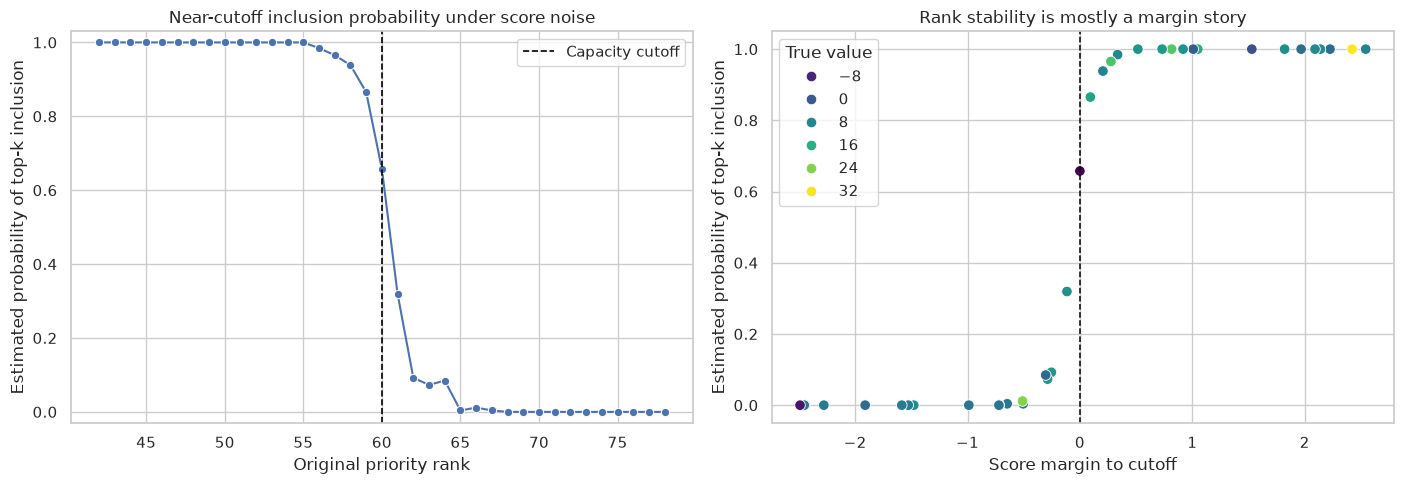

In [14]:
# Section focus: 11. Rank Stability Near The Cutoff.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

rng = np.random.default_rng(RANDOM_SEED + 17)
base_scores = test_eval['priority_score'].to_numpy()
score_noise_sd = np.std(base_scores) * 0.035
n_reps = 260
inclusion_counts = np.zeros(len(test_eval), dtype=int)

for _ in range(n_reps):
    noisy_scores = base_scores + rng.normal(0, score_noise_sd, size=len(base_scores))
    inclusion_counts[top_k_indices(noisy_scores, K)] += 1

test_eval['topk_inclusion_probability'] = inclusion_counts / n_reps
stability_window = test_eval.loc[test_eval['priority_rank'].between(K - 18, K + 18), [
    'priority_rank', 'priority_score', 'score_margin_to_cutoff', 'topk_inclusion_probability',
    'true_priority_value_k', 'contract_value_k', 'true_churn_risk'
]].copy()

display_table(stability_window.head(12))

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.0))
sns.lineplot(data=stability_window, x='priority_rank', y='topk_inclusion_probability', marker='o', ax=axes[0], color='#4c72b0')
axes[0].axvline(K, color='black', linestyle='--', linewidth=1.2, label='Capacity cutoff')
axes[0].set_title('Near-cutoff inclusion probability under score noise')
axes[0].set_xlabel('Original priority rank')
axes[0].set_ylabel('Estimated probability of top-k inclusion')
axes[0].set_ylim(-0.03, 1.03)
axes[0].legend()

sns.scatterplot(data=stability_window, x='score_margin_to_cutoff', y='topk_inclusion_probability', hue='true_priority_value_k', palette='viridis', s=58, ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.1)
axes[1].set_title('Rank stability is mostly a margin story')
axes[1].set_xlabel('Score margin to cutoff')
axes[1].set_ylabel('Estimated probability of top-k inclusion')
axes[1].legend(title='True value', loc='best')

plt.tight_layout()
plt.show()

Read Rank Stability Near The Cutoff as a communication test. A stakeholder-ready explanation should survive review and remain understandable.


### Discussion of Stability

The inclusion-probability curve should be steep near the cutoff. Accounts far above the cutoff are almost always selected. Accounts far below it are almost never selected. The interesting governance region is the band where inclusion probability is neither close to 0 nor close to 1.

For those cases, a defensible explanation should avoid overclaiming. A good message is: "This case is close to the current capacity boundary; its selection is sensitive to small score changes." That is more accurate than pretending that rank 60 is meaningfully different from rank 61.

## 12. A Professional Ranking Explanation Template

A ranked decision report should connect model behavior to policy behavior. A useful template is:

| Report component | What to include |
|---|---|
| Queue purpose | What action is being prioritized and why capacity is limited |
| Score semantics | Whether the score means risk, expected value, urgency, compliance priority, or something else |
| Ranking metric | Precision at k, value capture, NDCG, or another top-weighted metric |
| Cutoff rule | Capacity $k$, score threshold, minimum margin, or hybrid rule |
| Local explanation | Why this item is high scoring |
| Pairwise explanation | Why this item is above a nearby alternative |
| Near-cutoff warning | Whether the case is stable or a close call |
| Exposure audit | Which groups receive attention and how exposure compares to merit |
| Policy caveat | Whether the score is predictive, causal, economic, or a blend |

For the focal selected account above, a disciplined explanation would say:

> This account is selected because its predicted priority value places it above the weekly capacity cutoff. Relative to a near-miss account, the local surrogate suggests that usage drop and training gap push it upward, while contract value and competitor signal push against that ranking advantage. Because the case is close to the cutoff and the surrogate fit is only moderate, the recommendation should be reviewed as a capacity-sensitive priority decision rather than as an absolute statement of need.

## 13. Key Takeaways

- Ranking explanations are about **relative position**, alongside individual scores.
- A score can mean risk, expected value, urgency, or policy priority; explanations must match that meaning.
- Top-k metrics such as value capture and NDCG are often more relevant than ordinary point prediction metrics.
- The cases near the cutoff require special care because small score changes can flip selection.
- Pairwise explanations are often more useful than standalone explanations for ranked queues.
- Exposure diagnostics help governance teams see how attention is allocated across groups.
- A ranking score needs causal evidence before it can support causal claims. If the policy claims expected intervention value, the response component needs causal evidence.

## References

- Burges, C., Shaked, T., Renshaw, E., Lazier, A., Deeds, M., Hamilton, N., & Hullender, G. (2005). *Learning to rank using gradient descent*. Proceedings of the 22nd International Conference on Machine Learning, 89-96. [https://doi.org/10.1145/1102351.1102363](https://doi.org/10.1145/1102351.1102363)
- Chapelle, O., Metlzer, D., Zhang, Y., & Grinspan, P. (2009). *Expected reciprocal rank for graded relevance*. Proceedings of the 18th ACM Conference on Information and Knowledge Management, 621-630. [https://doi.org/10.1145/1645953.1646033](https://doi.org/10.1145/1645953.1646033)
- Järvelin, K., & Kekäläinen, J. (2002). *Cumulated gain-based evaluation of IR techniques*. ACM Transactions on Information Systems, 20(4), 422-446. [https://doi.org/10.1145/582415.582418](https://doi.org/10.1145/582415.582418)
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why should I trust you?": Explaining the predictions of any classifier*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 1135-1144. [https://doi.org/10.1145/2939672.2939778](https://doi.org/10.1145/2939672.2939778)
- Singh, A., & Joachims, T. (2018). *Fairness of exposure in rankings*. Proceedings of the 24th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, 2219-2228. [https://doi.org/10.1145/3219819.3220088](https://doi.org/10.1145/3219819.3220088)
